# Medical Insurance Cost Prediction

# 1. Importing Libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# 2. Data Collection

In [2]:
medical_dataset = pd.read_csv('insurance.csv')

In [3]:
medical_dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# 3. Data Preprocessing

In [4]:
medical_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
medical_dataset.shape

(1338, 7)

## Checking for missing values

In [6]:
medical_dataset.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

# Describing the Data

In [7]:
medical_dataset.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


# 4. Exploratory Data Analysis

## Let's see graphically the distribution of Age

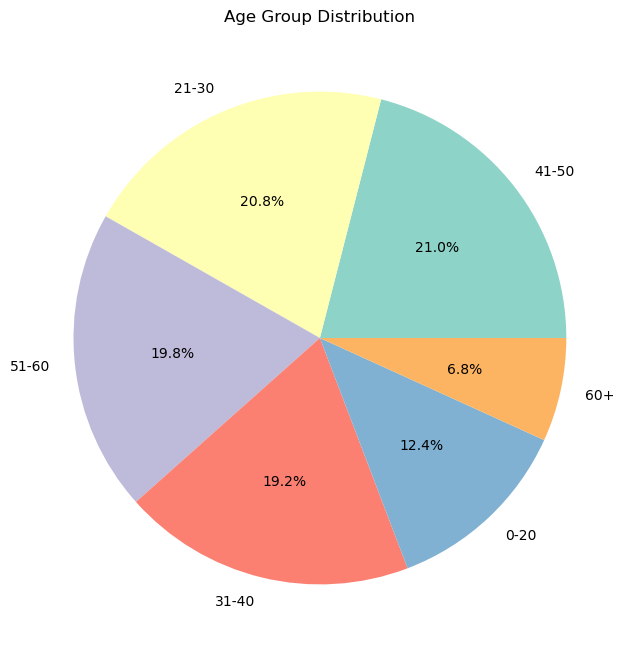

In [8]:
# Create age groups
bins = [0, 20, 30, 40, 50, 60, 100]
labels = ['0-20', '21-30', '31-40', '41-50', '51-60', '60+']

medical_dataset['age_group'] = pd.cut(medical_dataset['age'], bins=bins, labels=labels)

age_group_counts = medical_dataset['age_group'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(age_group_counts,
        labels=age_group_counts.index,
        autopct='%1.1f%%',
        colors=plt.cm.Set3.colors)

plt.title('Age Group Distribution')
plt.show()

## Let's see the SEX 

C:\Users\patil\AppData\Local\Temp\ipykernel_20960\1041649580.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sex',


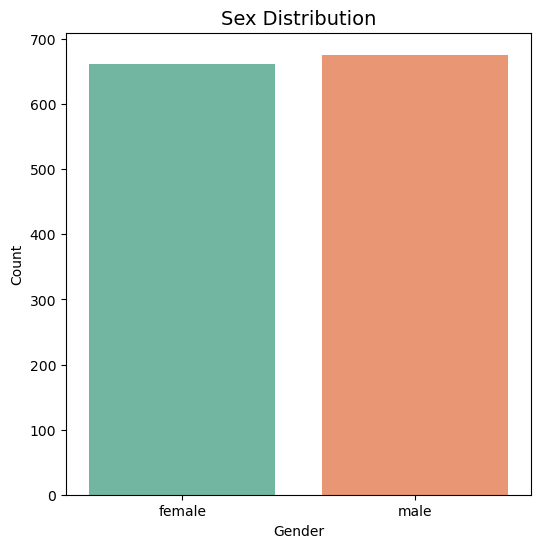

In [9]:
plt.figure(figsize=(6,6))
sns.countplot(x='sex',
              data=medical_dataset,
              palette='Set2')

plt.title('Sex Distribution', fontsize=14)
plt.xlabel('Gender')
plt.ylabel('Count')

plt.show()

## Counting number of males and females

In [10]:
medical_dataset['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

## Childrens one having

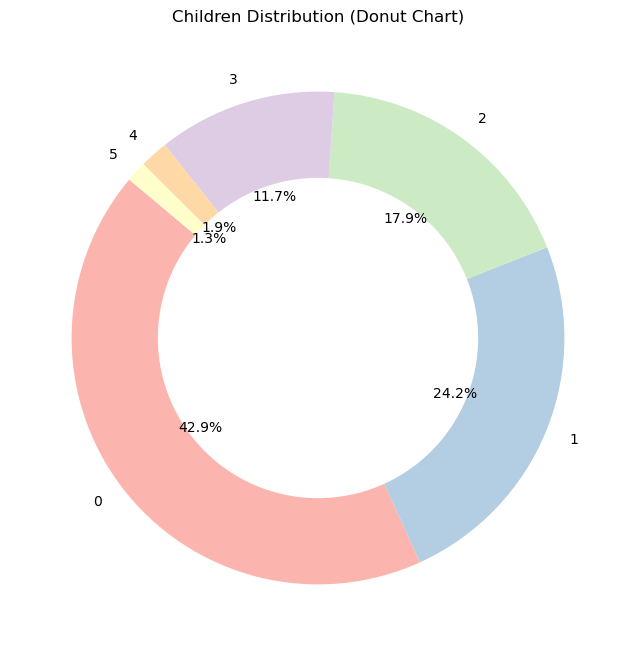

In [11]:
import matplotlib.pyplot as plt

# Step 1: Count children values
children_counts = medical_dataset['children'].value_counts().sort_index()

# Step 2: Create donut chart
plt.figure(figsize=(8,8))

plt.pie(children_counts,
        labels=children_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=plt.cm.Pastel1.colors)

# Create white center circle
centre_circle = plt.Circle((0,0), 0.65, fc='white')
plt.gca().add_artist(centre_circle)

plt.title('Children Distribution (Donut Chart)')
plt.show()

## Smokers Columns visualization

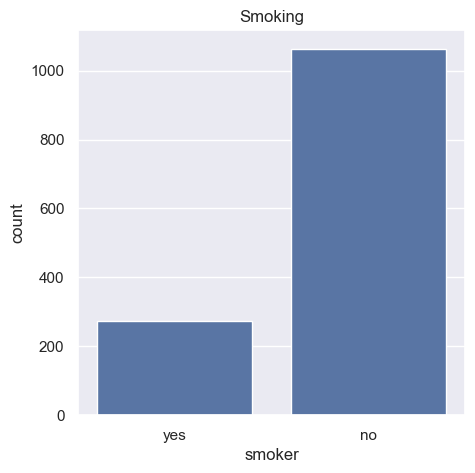

In [12]:
sns.set()
plt.figure(figsize=(5,5))
sns.countplot(x='smoker',data=medical_dataset)
plt.title('Smoking')
plt.show()

## Which region people are applying for

C:\Users\patil\AppData\Local\Temp\ipykernel_20960\3227404971.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='region', data=medical_dataset, palette='Set2')


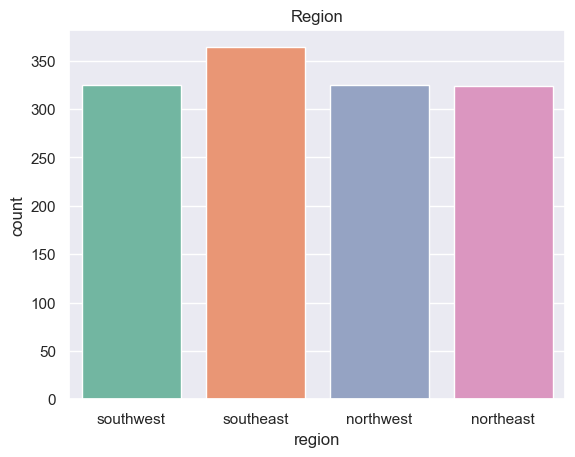

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set()
sns.countplot(x='region', data=medical_dataset, palette='Set2')
plt.title('Region')
plt.show()

In [14]:
medical_dataset['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

# 5. Encoding Categorical Columns
# Making the Smoker column and Region column into numerical values

In [35]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

medical_dataset['smoker'] = le.fit_transform(medical_dataset['smoker'])
medical_dataset['region'] = le.fit_transform(medical_dataset['region'])

In [43]:
# Load dataset
medical_dataset = pd.read_csv("insurance.csv")

# Encoding categorical columns
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
medical_dataset['sex'] = le.fit_transform(medical_dataset['sex'])
medical_dataset['smoker'] = le.fit_transform(medical_dataset['smoker'])
medical_dataset['region'] = le.fit_transform(medical_dataset['region'])

# Split features and target
X = medical_dataset.drop(columns='charges', axis=1)
Y = medical_dataset['charges']

# 6. Splitting the Data


In [44]:
X = medical_dataset.drop(columns='charges',axis=1)
Y = medical_dataset['charges']

In [45]:
print(X)

      age  sex     bmi  children  smoker  region
0      19    0  27.900         0       1       3
1      18    1  33.770         1       0       2
2      28    1  33.000         3       0       2
3      33    1  22.705         0       0       1
4      32    1  28.880         0       0       1
...   ...  ...     ...       ...     ...     ...
1333   50    1  30.970         3       0       1
1334   18    0  31.920         0       0       0
1335   18    0  36.850         0       0       2
1336   21    0  25.800         0       0       3
1337   61    0  29.070         0       1       1

[1338 rows x 6 columns]


In [46]:
print(Y)

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64


## Splitting the data into train test data

In [47]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [48]:
print(X.shape, X_train.shape, X_test.shape)

(1338, 6) (1070, 6) (268, 6)


## 7. Model Training


In [49]:
# loading the Linear Regression model
regressor = LinearRegression()

In [50]:
regressor.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# Model Evaluation

In [51]:
training_data_prediction = regressor.predict(X_train)
r2_train = metrics.r2_score(Y_train,training_data_prediction)
print(r2_train)

0.7519923667088932


In [52]:
# prediciting the test data
test_data_predicition = regressor.predict(X_test)
r2_test = metrics.r2_score(Y_test,test_data_predicition)

In [53]:
print(r2_test)

0.7445422986536503


# Prediction


# 'male':0,'female':1
## 'yes':0,'no': 1
## 'southeast':0,'southwest':1,'northeast':2,'northwest':3

In [54]:
input_data = (37,1,30.8,2,1,0)

#chaning it to numpy array
input_data_as_array = np.asarray(input_data)

#reshapping the data
input_data_reshaped = input_data_as_array.reshape(1,-1)

prediction = regressor.predict(input_data_reshaped)

print("The person will get insurance money = ",prediction[0])




The person will get insurance money =  32789.20569191889


C:\Users\patil\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


**Train-Test Split**

In [55]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = medical_dataset.drop(columns='charges', axis=1)
y = medical_dataset['charges']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Linear Regression Model**

In [56]:


from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Create model
lr_model = LinearRegression()

# Train model
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)

# Evaluation
lr_r2 = r2_score(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression R2 Score:", lr_r2)
print("Linear Regression RMSE:", lr_rmse)

Linear Regression R2 Score: 0.7833463107364539
Linear Regression RMSE: 5799.587091438356


**Random Forest Model (Better Model)**

In [57]:
from sklearn.ensemble import RandomForestRegressor

# Create model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation
rf_r2 = r2_score(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest R2 Score:", rf_r2)
print("Random Forest RMSE:", rf_rmse)

Random Forest R2 Score: 0.8642606273649586
Random Forest RMSE: 4590.5735387944


## 8. Model Evaluation


In [58]:
print("Linear Regression R2:", lr_r2)
print("Random Forest R2:", rf_r2)


Linear Regression R2: 0.7833463107364539
Random Forest R2: 0.8642606273649586


**Accuracy Improvement**


**1. Use One-Hot Encoding (Improves Accuracy)**


In [59]:
medical_dataset = pd.get_dummies(medical_dataset, columns=['region'], drop_first=True)


**2. Hyperparameter Tuning (Boost Random Forest)**

In [60]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Improved RF R2:", r2_score(y_test, y_pred_rf))


Improved RF R2: 0.8687624705106942


**3. Feature Scaling (For Linear Regression)**

In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

print("Scaled Linear Regression R2:", r2_score(y_test, y_pred_lr))

Scaled Linear Regression R2: 0.7833463107364537


In [62]:
import pickle
pickle.dump(rf_model, open("model.pkl", "wb"))

## 9. Conclusion

Random Forest Regressor performed better than Linear Regression 
with a higher R2 score and lower RMSE value.

Therefore, Random Forest is selected as the final model 
for predicting medical insurance costs.
